# Monte Carlo Primer -- When, Why, Sampling Pitfalls

A single-point risk estimate ("our expected annual loss is \$ 2.4M") invites false precision. The executive hears a number; the number becomes a budget line; the budget line becomes a commitment. But the estimate was uncertain to begin with -- the real outcome might be \$800K or \$12M.

Monte Carlo simulation replaces the single point with a **distribution of outcomes**. Instead of "\$2.4M," you report "\$1.1M to \$5.8M at 90% confidence, with a median of \$2.1M." This framing:

- Communicates uncertainty honestly,
- Supports threshold-based decisions ("is there more than a 10% chance we exceed our risk appetite?"), and
- Naturally accommodates the skewed, heavy-tailed distributions that dominate security loss data.

This notebook builds the core Monte Carlo workflow from scratch: compound Poisson loss simulation, convergence diagnostics, risk band extraction, VaR/ES tail measures, baseline-vs-control sensitivity analysis, and reproducibility practices.

## Setup

We use `decision-security`'s Monte Carlo engine (`simulate_aggregate_losses`),
risk band functions, and visualization helpers.

In [16]:
import numpy as np
import matplotlib.pyplot as plt

from decision_security.synth import make_rng, sample
from decision_security.montecarlo import (
    simulate_aggregate_losses,
    make_lognormal_severity,
    risk_bands,
    var_es,
)
from decision_security.viz import plot_risk_bands, plot_loss_distribution

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PRIMARY = "#1A1A1A"
ACCENT = "#E74C3C"
DARK_BG = "#34495E"
LIGHT_GRAY = "#95A5A6"
MED_GRAY = "#7F8C8D"
VERY_LIGHT = "#BDC3C7"


## Standard Error $\sim 1/\sqrt{N}$

Every Monte Carlo estimate is a sample statistic with a **standard error** (SE) that shrinks as $1/\sqrt{N}$. Doubling precision requires quadrupling samples. For the mean of the output distribution, $N = 10{,}000$ typically gives SE below 1% of the estimate. For the 95th percentile, convergence is slower because fewer samples populate the tail.

In practice, **$N = 10{,}000$** is a good default for exploratory analysis. For published results or board-level reporting, use **$N = 100{,}000$** and check stability by running twice with different seeds. If the p95 shifts by more than 5% between runs, you need more samples -- or your tail model itself is unstable.

Below we compute the mean of a lognormal sample at three sizes and watch the estimate stabilize.

In [2]:
rng = make_rng(42)

for n in [100, 1_000, 10_000]:
    draws = sample("lognormal", n, rng=rng, meanlog=10, sdlog=2)
    se = draws.std(ddof=1) / np.sqrt(n)
    print(f"N={n:>6,}  mean={draws.mean():>14,.2f}  SE={se:>12,.2f}")

N=   100  mean=     61,573.99  SE=   16,758.39
N= 1,000  mean=    149,904.07  SE=   20,210.73
N=10,000  mean=    166,864.65  SE=    9,994.51


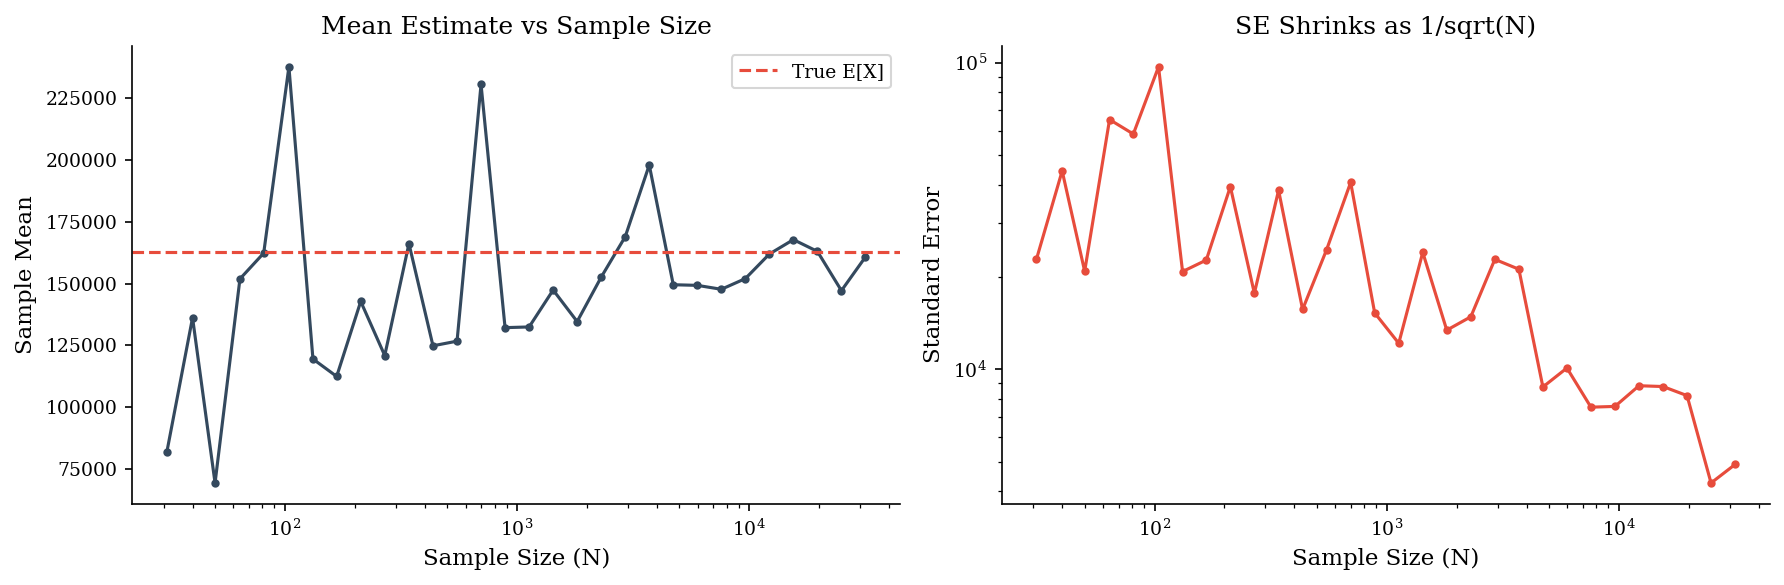

In [3]:
rng = make_rng(99)
sizes = np.logspace(1.5, 4.5, 30, dtype=int)
means = []
ses = []
for n in sizes:
    draws = sample("lognormal", n, rng=rng, meanlog=10, sdlog=2)
    means.append(draws.mean())
    ses.append(draws.std() / np.sqrt(n))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(sizes, means, "o-", markersize=3, color=DARK_BG)
axes[0].axhline(np.exp(10 + 2**2/2), color=ACCENT, linestyle="--", label="True E[X]")
axes[0].set_xscale("log")
axes[0].set_xlabel("Sample Size (N)")
axes[0].set_ylabel("Sample Mean")
axes[0].set_title("Mean Estimate vs Sample Size")
axes[0].legend()

axes[1].plot(sizes, ses, "o-", markersize=3, color=ACCENT)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("Sample Size (N)")
axes[1].set_ylabel("Standard Error")
axes[1].set_title("SE Shrinks as 1/sqrt(N)")
plt.tight_layout()
plt.show()

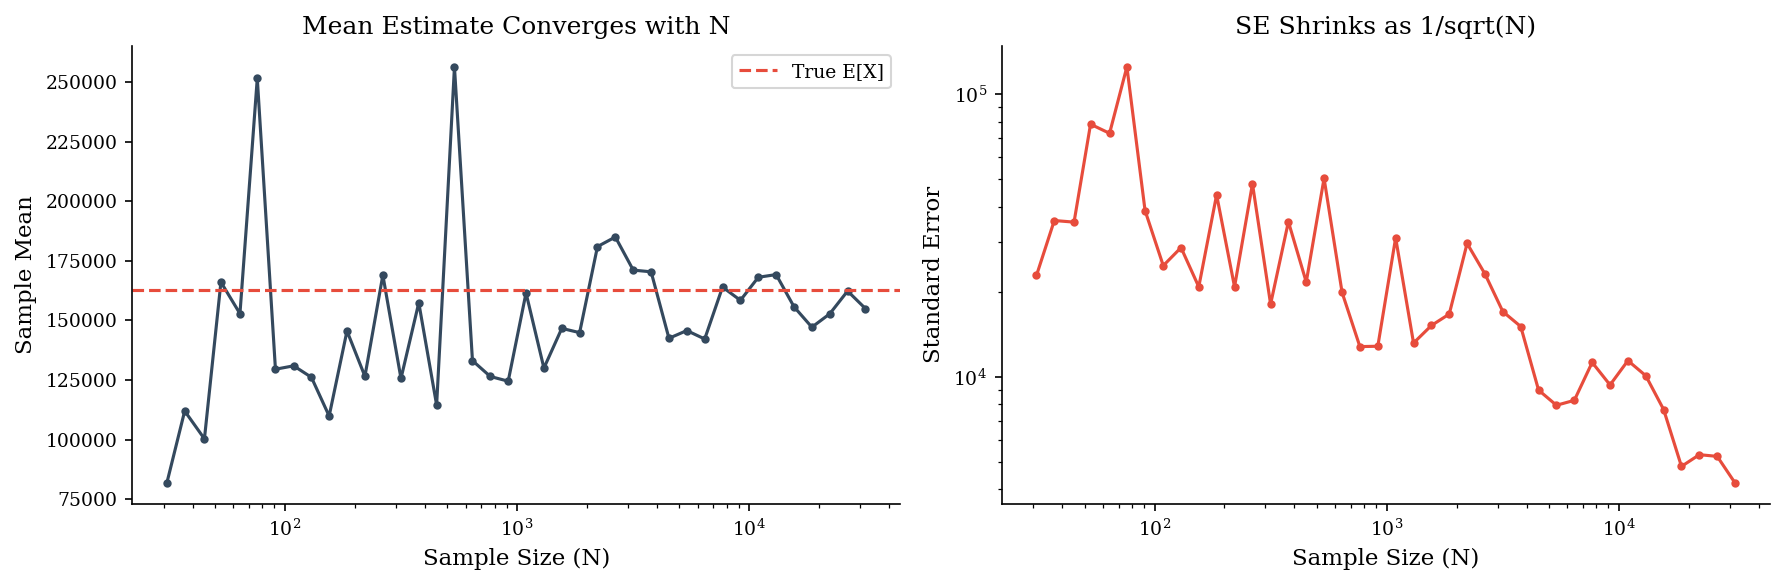

In [4]:
rng_conv = make_rng(99)
sizes = np.unique(np.logspace(1.5, 4.5, 40).astype(int))
se_vals = []
mean_vals = []
for n in sizes:
    draws = sample('lognormal', n, rng=rng_conv, meanlog=10, sdlog=2)
    mean_vals.append(draws.mean())
    se_vals.append(draws.std() / np.sqrt(n))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sizes, mean_vals, 'o-', markersize=3, color=DARK_BG)
axes[0].axhline(np.exp(10 + 2**2 / 2), color=ACCENT, linestyle='--', label='True E[X]')
axes[0].set_xscale('log')
axes[0].set_xlabel('Sample Size (N)')
axes[0].set_ylabel('Sample Mean')
axes[0].set_title('Mean Estimate Converges with N')
axes[0].legend()

axes[1].plot(sizes, se_vals, 'o-', markersize=3, color=ACCENT)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Sample Size (N)')
axes[1].set_ylabel('Standard Error')
axes[1].set_title('SE Shrinks as 1/sqrt(N)')

plt.tight_layout()
plt.show()

As N grows by 10x, the standard error drops by roughly $\sqrt{10} \approx 3.2\text{x}$.
The left plot shows the sample mean converging toward the true expectation.
The right plot shows SE on a log-log scale -- the slope of roughly $-0.5$ confirms
the $1/\sqrt{N}$ relationship.

**Practical rule of thumb:** 10,000 runs gives stable p50 and p90 estimates.
For p95 and beyond, you may need 50,000--100,000 runs -- the tail is always
the last thing to converge.

> **Note:** Tail quantiles converge much more slowly than means. At $N = 10{,}000$, your p50 estimate is rock-solid, your p90 is decent, and your p99 is still noisy. Always report tail estimates with a caveat about simulation precision.

## Compound Poisson Loss Model

The workhorse of FAIR-style risk quantification is the **compound Poisson model**: draw a frequency $n$ from $\text{Poisson}(\lambda)$, then draw $n$ independent severity values from a loss distribution (typically lognormal), and sum them. One iteration gives one simulated annual loss. Repeat $N$ times to build the loss exceedance curve.

In pseudocode:

```
for each simulation run:
    n_events = Poisson(lambda)
    losses   = [Lognormal(mu, sigma) for _ in range(n_events)]
    annual_loss = sum(losses)
```

This three-line loop is the core of virtually every cyber risk quantification engine. Everything else -- controls modeling, scenario comparison, portfolio aggregation -- is layered on top of this basic structure.

In [5]:
rng = make_rng(42)
sev = make_lognormal_severity(10, 2)
losses = simulate_aggregate_losses(10_000, 0.6, sev, rng=rng)

print(f"Simulated {len(losses):,} periods")
print(f"Zero-loss periods: {(losses == 0).sum():,} ({(losses == 0).mean():.1%})")
print(f"Mean aggregate loss: ${losses.mean():,.0f}")

Simulated 10,000 periods
Zero-loss periods: 5,405 (54.0%)
Mean aggregate loss: $100,899


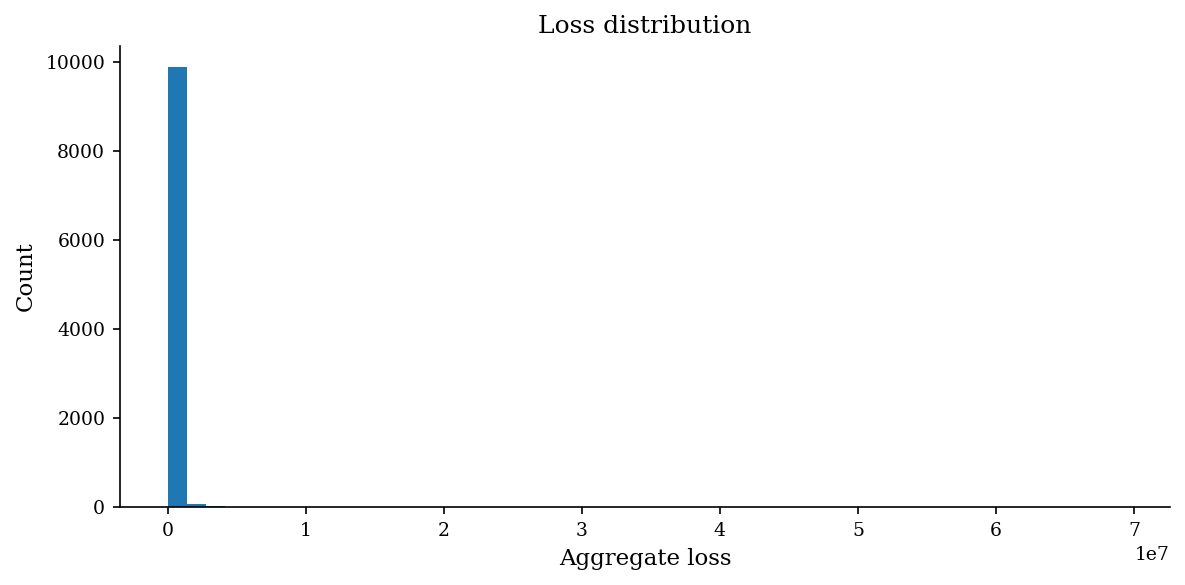

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_loss_distribution(losses, ax=ax)
plt.tight_layout()
plt.show()

## Risk Bands

The simulated loss distribution gives you a full menu of quantiles. Each maps to a different decision context:

- **p50 (median):** The "typical year" outcome. Use for expected budgeting and resource planning.
- **p90:** The stress case. Use for setting risk appetite thresholds and insurance retention levels.
- **p95:** The planning ceiling. Use for capital reserves, worst-case staffing, and board-level risk reporting.

When communicating results, the **p50--p90 band** is the most useful single summary: "In a typical year we expect \$1--3M in losses; in a bad year, up to \$7M." This framing gives decision-makers both a planning anchor and a stress boundary.

In [7]:
bands = risk_bands(losses)
for label, value in bands.items():
    print(f"{label}: ${value:>14,.0f}")

p50: $             0
p90: $       158,928
p95: $       385,922


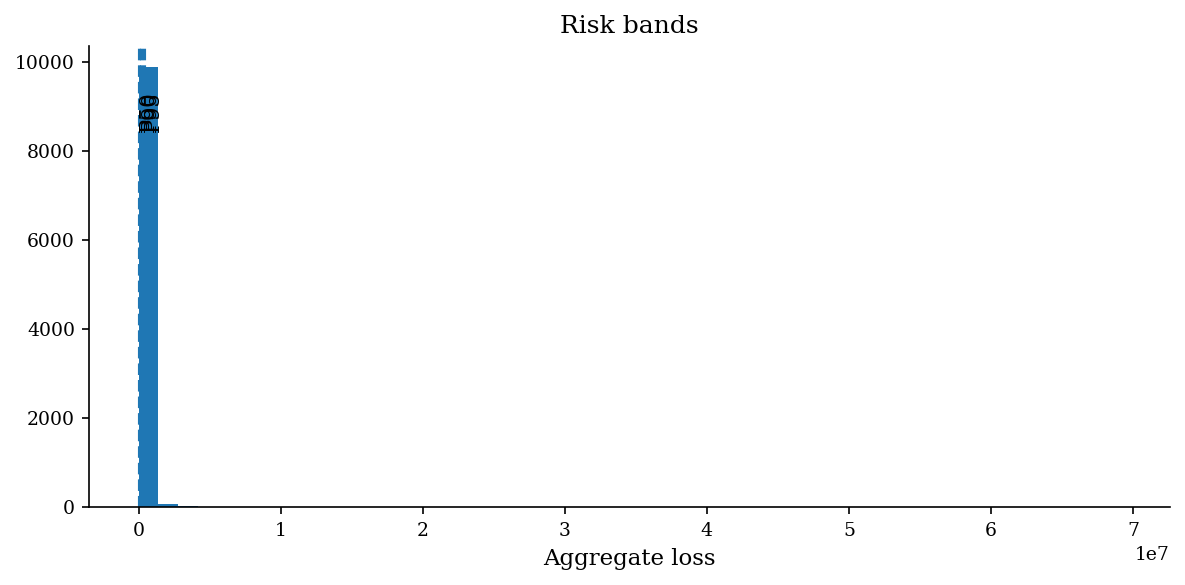

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_risk_bands(losses, ax=ax)
plt.tight_layout()
plt.show()

## Value-at-Risk and Expected Shortfall

**Value at Risk (VaR)** at confidence level $\alpha$ is simply the $\alpha$-quantile of the loss distribution: "there is only a $(1-\alpha)$ probability that losses exceed VaR." It answers "how bad could it get?" but says nothing about *how much worse* beyond that threshold.

**Expected Shortfall (ES)**, also called Conditional VaR or Tail VaR, is the average loss *given that* losses exceed the VaR threshold:

$$ES_\alpha = \mathbb{E}[L \mid L > \text{VaR}_\alpha]$$

ES is strictly more informative for heavy-tailed distributions because it captures tail severity, not just tail probability.

Use VaR for threshold-based decisions (SLAs, appetite statements). Use ES when you need to understand the magnitude of tail outcomes -- for instance, when sizing cyber insurance limits or evaluating whether a catastrophic scenario is survivable.

> **Tip:** In regulatory risk frameworks (Basel III, Solvency II), ES has largely replaced VaR precisely because VaR ignores what happens beyond the threshold. Security risk programs that adopt ES thinking are better prepared for the "how bad could it really get?" question.

In [9]:
v, es = var_es(losses, 0.95)
print(f"VaR(95%): ${v:>14,.0f}")
print(f" ES(95%): ${es:>14,.0f}")

VaR(95%): $       385,860
 ES(95%): $     1,513,947


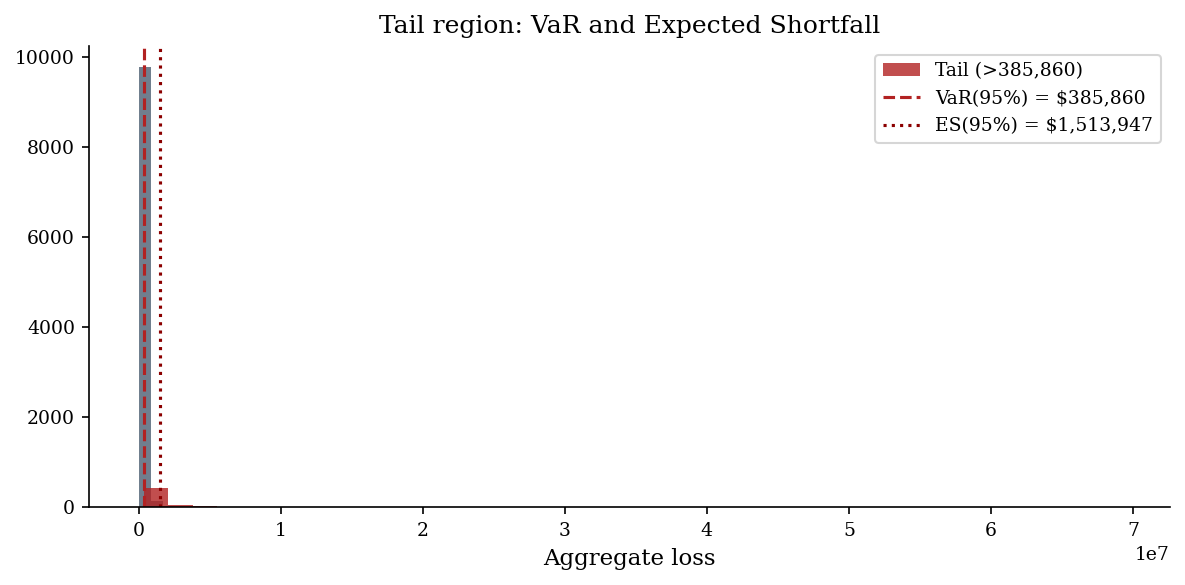

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
sorted_losses = np.sort(losses)
ax.hist(sorted_losses, bins=80, color=DARK_BG, edgecolor="none", alpha=0.7)

# Shade the tail region beyond VaR
tail = sorted_losses[sorted_losses >= v]
ax.hist(tail, bins=40, color="firebrick", edgecolor="none", alpha=0.8, label=f"Tail (>{v:,.0f})")

ax.axvline(v, color="firebrick", ls="--", lw=1.5, label=f"VaR(95%) = ${v:,.0f}")
ax.axvline(es, color="darkred", ls=":", lw=1.5, label=f"ES(95%) = ${es:,.0f}")
ax.set_xlabel("Aggregate loss")
ax.set_title("Tail region: VaR and Expected Shortfall")
ax.legend()
plt.tight_layout()
plt.show()

## Sensitivity: Baseline vs. Control Scenario

Monte Carlo makes scenario comparison trivial. Run the simulation twice: once with current parameters (baseline) and once with modified parameters (e.g., after deploying a new control that reduces frequency by 40%). The difference in output distributions is the control's **risk reduction**.

Compare p50 and p90 across scenarios, not just means. A control might reduce the mean loss modestly but dramatically compress the tail -- or vice versa. Showing the shift in the full distribution, not just a single number, gives stakeholders a much richer picture of the control's value.

For formal sensitivity analysis, vary one input at a time across its plausible range and record the change in output p90. A **tornado chart** of these sensitivities reveals which input assumptions matter most -- and therefore where better data collection or expert calibration has the highest payoff.

Below we deploy an EDR solution that halves the expected event frequency from $\lambda=0.6$ to $\lambda=0.3$ and overlay the two loss distributions.

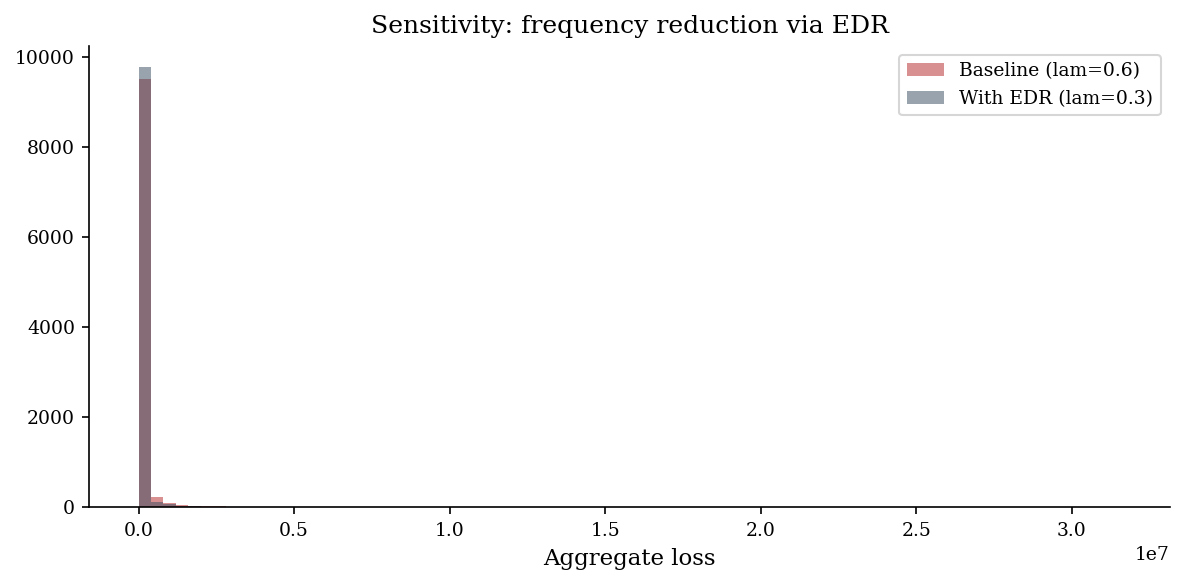

In [11]:
rng_base = make_rng(99)
rng_edr = make_rng(99)

sev = make_lognormal_severity(10, 2)
losses_base = simulate_aggregate_losses(10_000, 0.6, sev, rng=rng_base)
losses_edr  = simulate_aggregate_losses(10_000, 0.3, sev, rng=rng_edr)

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, max(losses_base.max(), losses_edr.max()), 80)
ax.hist(losses_base, bins=bins, alpha=0.5, label="Baseline (lam=0.6)", color="firebrick")
ax.hist(losses_edr, bins=bins, alpha=0.5, label="With EDR (lam=0.3)", color=DARK_BG)
ax.set_xlabel("Aggregate loss")
ax.set_title("Sensitivity: frequency reduction via EDR")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
print("Risk bands comparison:")
print(f"{'':>8} {'Baseline':>14} {'With EDR':>14} {'Reduction':>12}")
rb_base = risk_bands(losses_base)
rb_edr  = risk_bands(losses_edr)
for k in rb_base:
    b = rb_base[k]
    e = rb_edr[k]
    pct = (b - e) / b * 100 if b > 0 else 0
    print(f"{k:>8} ${b:>13,.0f} ${e:>13,.0f} {pct:>10.1f}%")

Risk bands comparison:
               Baseline       With EDR    Reduction
     p50 $            0 $            0        0.0%
     p90 $      159,257 $       54,501       65.8%
     p95 $      385,307 $      162,323       57.9%


## Reproducibility

Monte Carlo results are random -- but they should be *reproducibly* random. Setting a random seed before simulation ensures identical results across runs, which is essential for debugging, peer review, and audit trails. In Python: `rng = np.random.default_rng(seed=42)`. Pass this generator to all sampling calls.

Always record and report the seed used. When presenting results, note "N = 50,000, seed = 42" so any reviewer can reproduce the exact output. For production risk reports, run with 3--5 different seeds and confirm that key quantiles are stable.

Always pass an explicit seed via `make_rng(seed)` in any analysis that will
be reported, reviewed, or compared across runs.

In [13]:
sev = make_lognormal_severity(10, 2)

run_a = simulate_aggregate_losses(1_000, 0.6, sev, rng=make_rng(7))
run_b = simulate_aggregate_losses(1_000, 0.6, sev, rng=make_rng(7))

print(f"Identical? {np.array_equal(run_a, run_b)}")
print(f"Run A mean: ${run_a.mean():,.2f}")
print(f"Run B mean: ${run_b.mean():,.2f}")

Identical? True
Run A mean: $95,155.16
Run B mean: $95,155.16


## Pitfalls to Watch For

1. **Small-N tail noise.** With $N = 1{,}000$, your p95 estimate is based on roughly 50 observations in the tail. That is not enough for a stable estimate, especially with heavy-tailed severity. Increase $N$ or acknowledge the imprecision explicitly. The demo below shows the instability at N=500.

2. **Ignored correlations.** The basic compound Poisson model assumes frequency and severity are independent, and that multiple risk scenarios are uncorrelated. In reality, a threat campaign may simultaneously increase frequency *and* severity, and correlated scenarios (e.g., supply-chain compromise affecting multiple systems) can produce aggregate losses far beyond what independent simulation predicts. Model correlations explicitly when they matter -- Part 2 covers copulas and correlated simulation.

3. **Unit and time-horizon mismatch.** If frequency is "per year" but severity data was collected "per incident over the last quarter," the resulting ALE will be wrong. Align all inputs to the same time horizon and unit basis before simulating. This sounds obvious but is the single most common error in practice.

In [14]:
# Demonstrate pitfall 1: small-N tail instability
sev = make_lognormal_severity(10, 2)
p95_estimates = []

for trial in range(20):
    small = simulate_aggregate_losses(500, 0.6, sev, rng=make_rng(trial))
    p95_estimates.append(np.quantile(small, 0.95))

print(f"P95 across 20 trials (N=500 each):")
print(f"  min = ${min(p95_estimates):>12,.0f}")
print(f"  max = ${max(p95_estimates):>12,.0f}")
print(f"  range ratio = {max(p95_estimates)/max(min(p95_estimates),1):.1f}x")
print("\nThis spread shrinks dramatically at N=10,000.")

P95 across 20 trials (N=500 each):
  min = $     287,070
  max = $     438,292
  range ratio = 1.5x

This spread shrinks dramatically at N=10,000.


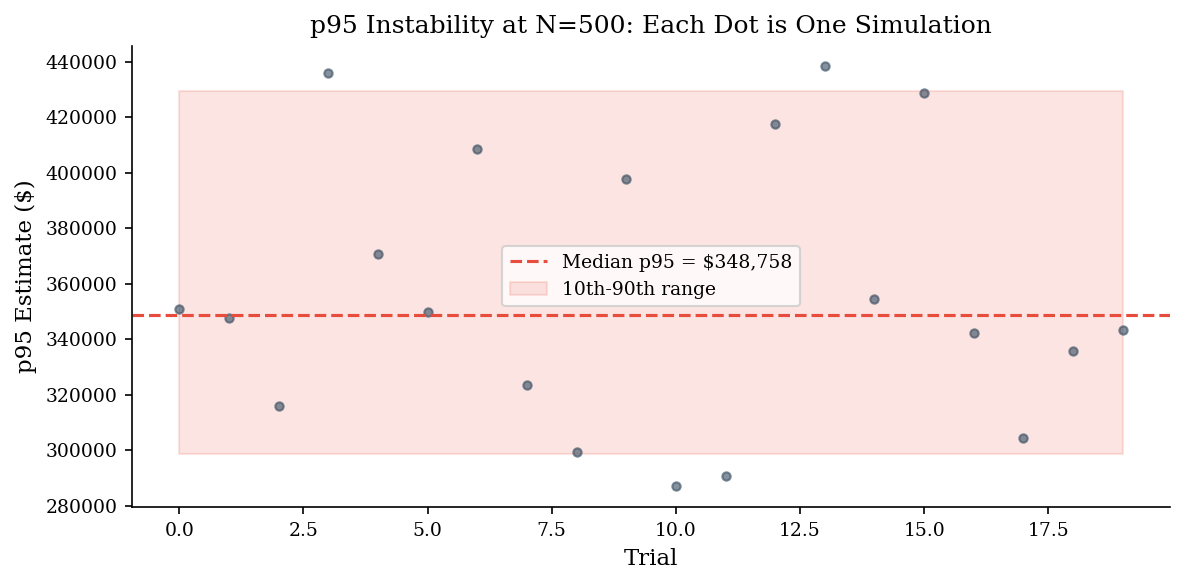

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(p95_estimates, "o", markersize=4, alpha=0.6, color=DARK_BG)
ax.axhline(np.median(p95_estimates), color=ACCENT, linestyle="--", label=f"Median p95 = ${np.median(p95_estimates):,.0f}")
ax.fill_between(range(len(p95_estimates)),
                np.percentile(p95_estimates, 10),
                np.percentile(p95_estimates, 90),
                alpha=0.15, color=ACCENT, label="10th-90th range")
ax.set_xlabel("Trial")
ax.set_ylabel("p95 Estimate ($)")
ax.set_title("p95 Instability at N=500: Each Dot is One Simulation")
ax.legend()
plt.tight_layout()
plt.show()